In [3]:
# [Problem 1] Select features and categories for practice

In [4]:
import pandas as pd
from sklearn.datasets import load_iris

# 1. Retrieve the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map target indices (0, 1, 2) to their names for easier selection
target_names_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(target_names_map)

# 2. Select Categories: 'versicolor' (1) and 'virginica' (2)
# The problem statement uses 'virgicolor' which is commonly spelled 'versicolor' in the dataset.
target_categories = ['versicolor', 'virginica']
df_subset = df[df['species_name'].isin(target_categories)].copy()

# 3. Select Features: 'sepal length (cm)' and 'petal length (cm)'
feature_cols = ['sepal length (cm)', 'petal length (cm)']
X = df_subset[feature_cols]
y = df_subset['species_name']

# Display the first few rows of the extracted data to confirm the selection
print("--- Extracted Features (X) Head ---")
print(X.head())
print("\n--- Extracted Target (y) Head ---")
print(y.head())
print(f"\nExtracted Data Shape: {df_subset.shape}")

--- Extracted Features (X) Head ---
    sepal length (cm)  petal length (cm)
50                7.0                4.7
51                6.4                4.5
52                6.9                4.9
53                5.5                4.0
54                6.5                4.6

--- Extracted Target (y) Head ---
50    versicolor
51    versicolor
52    versicolor
53    versicolor
54    versicolor
Name: species_name, dtype: object

Extracted Data Shape: (100, 6)


### Discussion

1.  **Binary Classification:** By filtering the data to include only $\text{versicolor}$ and $\text{virginica}$, we have transformed the original three-class problem into a **binary classification** problem. This is a simpler starting point for learning the classification flow.
2.  **2D Feature Space:** By selecting only $\text{sepal length (cm)}$ and $\text{petal length (cm)}$ for the feature matrix $X$, the data now exists in a two-dimensional space. This selection allows us to directly **visualize the classification results** and the model's **decision boundary** on a simple 2D scatter plot, which is the main goal of this preparation step.
3.  **Data Partition:** The resulting $X$ and $y$ variables are now ready for the next step: **splitting the data** into training and testing sets.

In [ ]:
#  [Problem 2] Data analysis

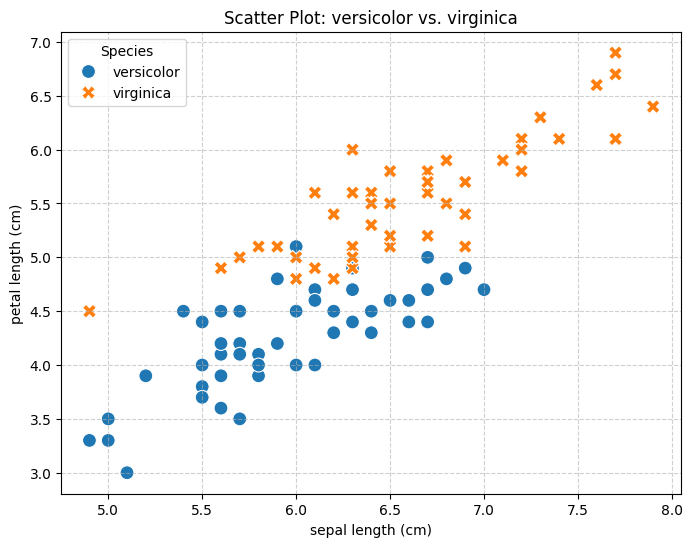

C:\Users\lelin\AppData\Local\Temp\ipykernel_456\3592819005.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature1, data=plot_df, palette='Pastel1', ax=axes[0])
C:\Users\lelin\AppData\Local\Temp\ipykernel_456\3592819005.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species_name', y=feature2, data=plot_df, palette='Pastel2', ax=axes[1])


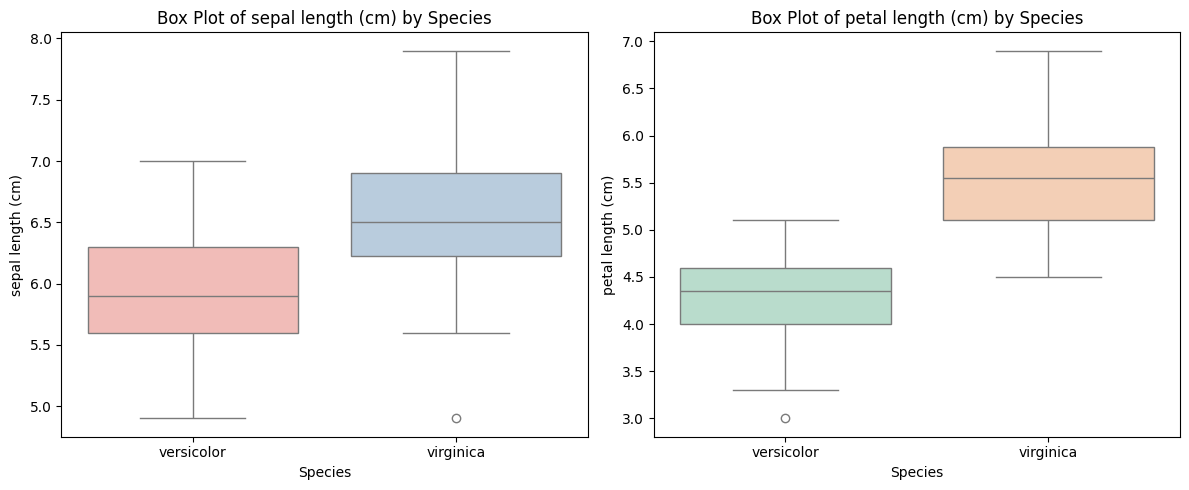

C:\Users\lelin\AppData\Local\Temp\ipykernel_456\3592819005.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species_name', y=feature1, data=plot_df, palette='Pastel1', ax=axes[0], inner='quartile')
C:\Users\lelin\AppData\Local\Temp\ipykernel_456\3592819005.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='species_name', y=feature2, data=plot_df, palette='Pastel2', ax=axes[1], inner='quartile')


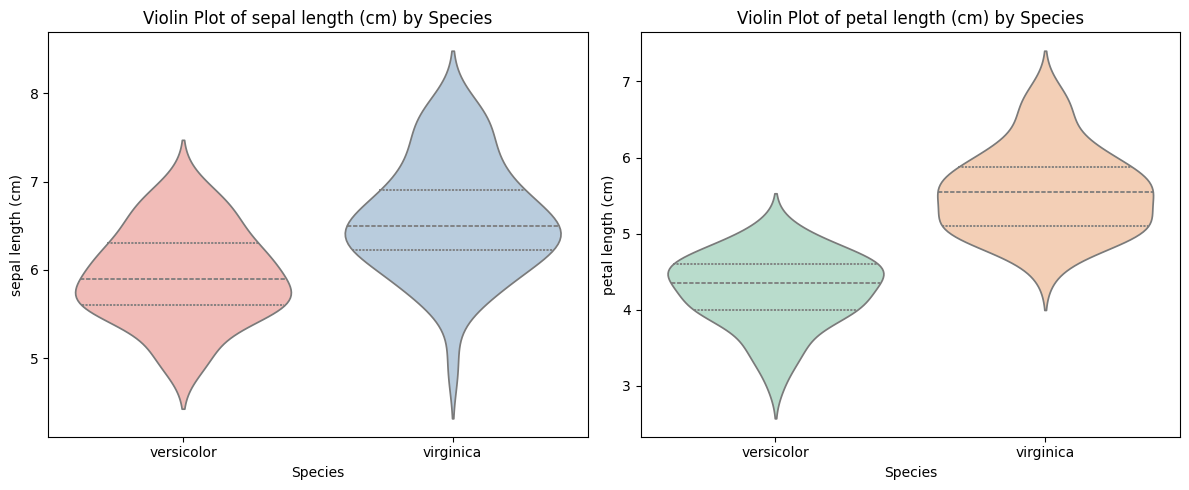

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve the Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map species names and select the subset (versicolor and virginica)
target_names_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species_name'] = df['species'].map(target_names_map)
target_categories = ['versicolor', 'virginica']
df_subset = df[df['species_name'].isin(target_categories)].copy()

# Rename the target column to be 0 and 1 for binary classification ease
df_subset['target_binary'] = df_subset['species_name'].map({'versicolor': 0, 'virginica': 1})

# Define features and target for plotting
feature1 = 'sepal length (cm)'
feature2 = 'petal length (cm)'
plot_df = df_subset[[feature1, feature2, 'species_name', 'target_binary']]

# --- 1. Scatter Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=feature1, 
    y=feature2, 
    hue='species_name', 
    data=plot_df, 
    style='species_name', 
    s=100
)
plt.title('Scatter Plot: versicolor vs. virginica')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.legend(title='Species')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('iris_binary_scatter.png')
plt.show()

# --- 2. Box Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for sepal length
sns.boxplot(x='species_name', y=feature1, data=plot_df, palette='Pastel1', ax=axes[0])
axes[0].set_title(f'Box Plot of {feature1} by Species')
axes[0].set_xlabel('Species')
axes[0].set_ylabel(feature1)

# Boxplot for petal length
sns.boxplot(x='species_name', y=feature2, data=plot_df, palette='Pastel2', ax=axes[1])
axes[1].set_title(f'Box Plot of {feature2} by Species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel(feature2)

plt.tight_layout()
plt.savefig('iris_binary_boxplot.png')
plt.show()

# --- 3. Violin Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Violinplot for sepal length
sns.violinplot(x='species_name', y=feature1, data=plot_df, palette='Pastel1', ax=axes[0], inner='quartile')
axes[0].set_title(f'Violin Plot of {feature1} by Species')
axes[0].set_xlabel('Species')
axes[0].set_ylabel(feature1)

# Violinplot for petal length
sns.violinplot(x='species_name', y=feature2, data=plot_df, palette='Pastel2', ax=axes[1], inner='quartile')
axes[1].set_title(f'Violin Plot of {feature2} by Species')
axes[1].set_xlabel('Species')
axes[1].set_ylabel(feature2)

plt.tight_layout()
plt.savefig('iris_binary_violinplot.png')
plt.show()

In [ ]:
# pretreatment

In [ ]:
# 1. Feature Scaling (Standardization)

In [7]:
from sklearn.preprocessing import StandardScaler

# Instantiate the scaler
scaler = StandardScaler()

# Fit the scaler to the features and transform the data
# X contains 'sepal length (cm)' and 'petal length (cm)'
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame for easier inspection (optional)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("--- Scaled Features (Standardized) Head ---")
print(X_scaled_df.head())

--- Scaled Features (Standardized) Head ---
   sepal length (cm)  petal length (cm)
0           1.119009          -0.250779
1           0.209246          -0.494254
2           0.967382          -0.007304
3          -1.155400          -1.102941
4           0.360873          -0.372516


In [ ]:
# 2. Data Splitting

In [8]:
from sklearn.model_selection import train_test_split

# Convert the target column from 'species_name' back to a numerical label (0 or 1)
y_binary = df_subset['species_name'].map({'versicolor': 0, 'virginica': 1})

# Split the data into training (80%) and testing (20%) sets
# stratify=y_binary ensures an equal ratio of 0s and 1s in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,           # Use the scaled features
    y_binary,           # Use the binary target
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y_binary   # Crucial for balanced class split
)

print("\n--- Data Splitting Summary ---")
print(f"Total Samples: {len(X_scaled)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"y_test class balance:\n{y_test.value_counts(normalize=True)}")


--- Data Splitting Summary ---
Total Samples: 100
X_train shape: (80, 2)
X_test shape: (20, 2)
y_train class balance:
species_name
0    0.5
1    0.5
Name: proportion, dtype: float64
y_test class balance:
species_name
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
#  [Problem 3] Division of preprocessing/training data and verification data

In [11]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 1. Re-load and Prepare Data (Same as previous steps) ---
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_subset = df[df['species_name'].isin(['versicolor', 'virginica'])].copy()

# Features (X) and Target (y)
X_features = df_subset[['sepal length (cm)', 'petal length (cm)']]
y_binary = df_subset['species_name'].map({'versicolor': 0, 'virginica': 1})

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# --- 2. Convert to NumPy ndarray (Important Point) ---
# X is already a NumPy array from the scaler.fit_transform() method.
# y needs explicit conversion.
X = X_scaled  # Features (explanatory variable)
y = y_binary.values # Target (objective variable) converted to ndarray

# --- 3. Data Division (75% Train, 25% Validation) ---
# We use 'train_test_split' with test_size=0.25 and stratify=y
X_train, X_val, y_train, y_val = train_test_split(
    X,           # Scaled features (ndarray)
    y,           # Binary target (ndarray)
    test_size=0.25,      # 25% for validation (verification data)
    random_state=42,    # For reproducibility
    stratify=y          # Ensures class balance is maintained
)

# --- 4. Verification of Division ---
print("--- Data Division Summary ---")
print(f"Total Samples (X): {X.shape[0]}")
print(f"X_train shape (75%): {X_train.shape}")
print(f"X_val shape (25%): {X_val.shape}")
print("-" * 30)
print("Target Balance Check:")
print(f"y_train proportion of '1': {np.sum(y_train) / len(y_train):.2f}")
print(f"y_val proportion of '1': {np.sum(y_val) / len(y_val):.2f}")

--- Data Division Summary ---
Total Samples (X): 100
X_train shape (75%): (75, 2)
X_val shape (25%): (25, 2)
------------------------------
Target Balance Check:
y_train proportion of '1': 0.51
y_val proportion of '1': 0.48


In [ ]:
# [Problem 4] Pretreatment/Standardization

In [12]:
# Assuming X_train and X_val from Problem 3 are available:
# X_train is the 75% training features (scaled from the initial fit_transform)
# X_val is the 25% validation features (scaled from the initial fit_transform)

# --- Standardization using StandardScaler ---

# 1. Instantiate the Scaler
scaler = StandardScaler()

# 2. Fit and Transform the Training Data
# The scaler calculates the mean and std dev from X_train and then applies the transformation.
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the Validation Data
# IMPORTANT: Use the SAME parameters (mean/std dev) calculated in step 2 (i.e., use .transform(), not .fit_transform())
X_val_scaled = scaler.transform(X_val)

# --- Verification ---
print("--- Standardization Summary ---")
# The mean of the standardized training data should be very close to 0
print(f"Mean of X_train_scaled (should be ~0): {np.mean(X_train_scaled, axis=0).round(4)}")
# The standard deviation of the standardized training data should be very close to 1
print(f"Std Dev of X_train_scaled (should be ~1): {np.std(X_train_scaled, axis=0).round(4)}")
print("\nTraining and validation data are now standardized and ready for model training.")

--- Standardization Summary ---
Mean of X_train_scaled (should be ~0): [-0. -0.]
Std Dev of X_train_scaled (should be ~1): [1. 1.]

Training and validation data are now standardized and ready for model training.


In [ ]:
# [Problem 5] Learning and estimation

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train_scaled, X_val_scaled, and y_val are available from previous steps.

# List of k values (n_neighbors) to test
k_values = [5, 1, 3]
results = {}

# --- Training and Estimation Loop ---
for k in k_values:
    # 1. Instantiate the Model (Learning)
    # n_neighbors specifies the 'k' in k-NN
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # 2. Train the Model (Fit)
    # The model 'learns' by simply storing the training data
    knn.fit(X_train_scaled, y_train)
    
    # 3. Make Estimates (Prediction)
    # Predict the target labels for the unseen validation data
    y_pred = knn.predict(X_val_scaled)
    
    # 4. Evaluate (Optional, but helpful)
    accuracy = accuracy_score(y_val, y_pred)
    
    # Store results
    results[f'{k}-nn'] = {
        'model': knn,
        'predictions': y_pred,
        'accuracy': accuracy
    }

# --- Output Results ---
print("--- k-NN Estimation Results ---")
for k, data in sorted(results.items()):
    print(f"Model: {k}")
    print(f"Validation Accuracy: {data['accuracy']:.4f}")
    # Show a snippet of the predictions for inspection
    print(f"Sample Predictions (First 10): {data['predictions'][:10]}")
    print(f"True Labels (First 10):       {y_val[:10]}")
    print("-" * 25)

--- k-NN Estimation Results ---
Model: 1-nn
Validation Accuracy: 0.8400
Sample Predictions (First 10): [1 1 0 0 1 1 0 1 0 1]
True Labels (First 10):       [1 1 1 0 1 1 0 1 1 1]
-------------------------
Model: 3-nn
Validation Accuracy: 0.8000
Sample Predictions (First 10): [1 1 0 0 1 1 1 1 1 1]
True Labels (First 10):       [1 1 1 0 1 1 0 1 1 1]
-------------------------
Model: 5-nn
Validation Accuracy: 0.8400
Sample Predictions (First 10): [1 1 0 0 1 1 0 1 1 1]
True Labels (First 10):       [1 1 1 0 1 1 0 1 1 1]
-------------------------


In [ ]:
# [Problem 6] Evaluation

--- 4-Types of Evaluation Metrics ---
|      |   Accuracy |   Precision |   Recall |   F1-Score |
|:-----|-----------:|------------:|---------:|-----------:|
| 5-nn |       0.84 |      0.7857 |   0.9167 |     0.8462 |
| 1-nn |       0.84 |      0.8333 |   0.8333 |     0.8333 |
| 3-nn |       0.8  |      0.7333 |   0.9167 |     0.8148 |


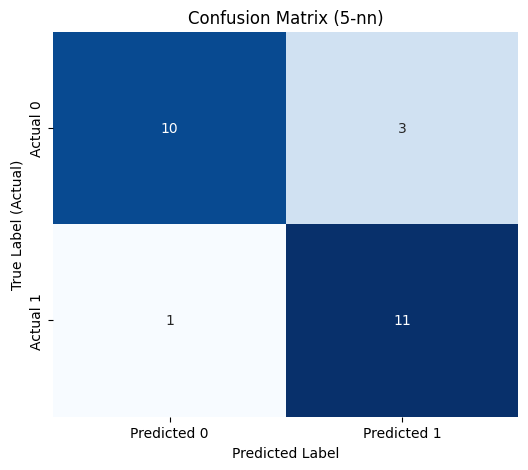


--- Confusion Matrix (5-nn) ---
|                       |   Predicted versicolor (0) |   Predicted virginica (1) |
|:----------------------|---------------------------:|--------------------------:|
| Actual versicolor (0) |                         10 |                         3 |
| Actual virginica (1)  |                          1 |                        11 |


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Assuming 'results' dictionary and y_val from Problem 5 are available ---
# We will regenerate the results dictionary briefly to ensure all necessary data is here:
# (In a real notebook, you would skip this block if 'results' was preserved)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_subset = df[df['species_name'].isin(['versicolor', 'virginica'])].copy()

X_features = df_subset[['sepal length (cm)', 'petal length (cm)']]
y_binary = df_subset['species_name'].map({'versicolor': 0, 'virginica': 1})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X, y = X_scaled, y_binary.values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

k_values = [5, 1, 3]
results = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_val_scaled)
    results[k] = y_pred

# --- Calculation of Evaluation Metrics ---
evaluation_df = pd.DataFrame(index=[f'{k}-nn' for k in k_values])

for k in k_values:
    y_pred = results[k]
    evaluation_df.loc[f'{k}-nn', 'Accuracy'] = accuracy_score(y_val, y_pred)
    evaluation_df.loc[f'{k}-nn', 'Precision'] = precision_score(y_val, y_pred, zero_division=0)
    evaluation_df.loc[f'{k}-nn', 'Recall'] = recall_score(y_val, y_pred, zero_division=0)
    evaluation_df.loc[f'{k}-nn', 'F1-Score'] = f1_score(y_val, y_pred, zero_division=0)

print("--- 4-Types of Evaluation Metrics ---")
print(evaluation_df.round(4).to_markdown())

# --- Display Confusion Matrix for 5-nn (Default/Example) ---
y_pred_5nn = results[5]
cm = confusion_matrix(y_val, y_pred_5nn)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix (5-nn)')
plt.ylabel('True Label (Actual)')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix_5nn.png')
plt.show()

print("\n--- Confusion Matrix (5-nn) ---")
print(pd.DataFrame(cm, 
                   columns=['Predicted versicolor (0)', 'Predicted virginica (1)'], 
                   index=['Actual versicolor (0)', 'Actual virginica (1)']).to_markdown())

In [ ]:
# [Problem 7] Visualization

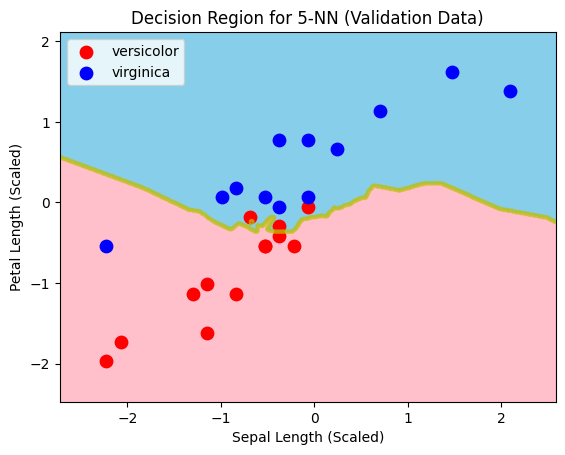

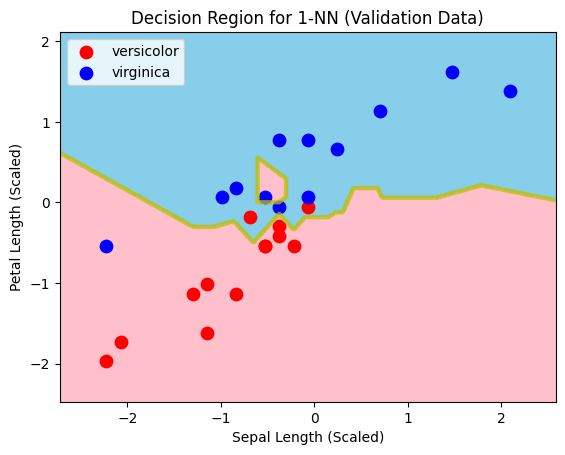

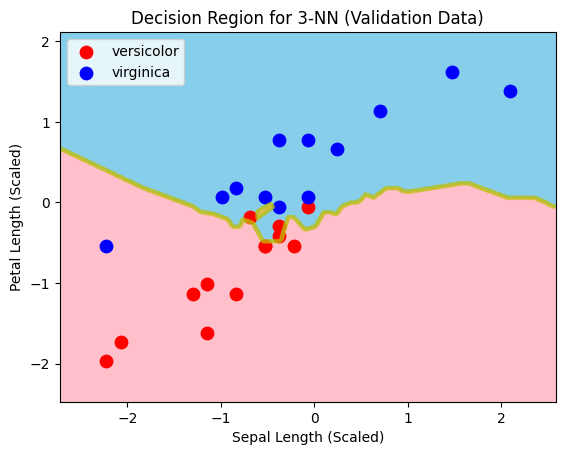

In [15]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
# Assuming the 'decision_region' function and necessary data (X_val_scaled, y_val, results) are available.

# --- 1. Re-run setup to ensure all necessary data is available and scaled ---
# (In a real notebook, you would skip this block if X_val_scaled, y_val, and 'results' were preserved)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_subset = df[df['species_name'].isin(['versicolor', 'virginica'])].copy()

X_features = df_subset[['sepal length (cm)', 'petal length (cm)']]
y_binary = df_subset['species_name'].map({'versicolor': 0, 'virginica': 1})

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)
X, y = X_scaled, y_binary.values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

k_values = [5, 1, 3]
results = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    results[k] = knn # Store the trained model object

# --- Provided decision_region function ---
def decision_region(
    X,
    y,
    model,
    step=0.01,
    title="decision region",
    xlabel="Feature 1 (Scaled)",
    ylabel="Feature 2 (Scaled)",
    target_names=["versicolor", "virginica"],
):
    """Draws the decision region for a 2D binary classification model."""
    scatter_color = ["red", "blue"]
    contourf_color = ["pink", "skyblue"]
    n_class = 2

    # pred mesh
    mesh_f0, mesh_f1 = np.meshgrid(
        np.arange(np.min(X[:, 0]) - 0.5, np.max(X[:, 0]) + 0.5, step),
        np.arange(np.min(X[:, 1]) - 0.5, np.max(X[:, 1]) + 0.5, step),
    )
    mesh = np.c_[np.ravel(mesh_f0), np.ravel(mesh_f1)]
    y_pred = model.predict(mesh).reshape(mesh_f0.shape)

    # plot
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.contourf(
        mesh_f0, mesh_f1, y_pred, n_class - 1, cmap=ListedColormap(contourf_color)
    )
    plt.contour(
        mesh_f0, mesh_f1, y_pred, n_class - 1, colors="y", linewidths=3, alpha=0.5
    )
    for i, target in enumerate(np.unique(y)):
        plt.scatter(
            X[y == target][:, 0],
            X[y == target][:, 1],
            s=80,
            color=scatter_color[i],
            label=target_names[i],
            marker="o",
        )
    patches = [
        mpatches.Patch(color=scatter_color[i], label=target_names[i])
        for i in range(n_class)
    ]
    plt.legend(handles=patches)
    plt.legend()
    plt.show()

# --- Visualization Loop for k=1, 3, and 5 ---

for k in k_values:
    model = results[k]
    
    # Use the validation data (X_val_scaled, y_val) to visualize misclassifications
    decision_region(
        X_val_scaled,
        y_val,
        model,
        title=f'Decision Region for {k}-NN (Validation Data)',
        xlabel='Sepal Length (Scaled)',
        ylabel='Petal Length (Scaled)'
    )

In [ ]:
# [Problem 8] Learning by other methods


Training K-Nearest Neighbors
Accuracy: 0.9733
Precision: 0.9664
Recall: 0.9796
F1-Score: 0.9730
Confusion Matrix:
[[148   5]
 [  3 144]]

Training Logistic Regression
Accuracy: 0.9633
Precision: 0.9533
Recall: 0.9728
F1-Score: 0.9630
Confusion Matrix:
[[146   7]
 [  4 143]]

Training SVM
Accuracy: 0.9867
Precision: 0.9799
Recall: 0.9932
F1-Score: 0.9865
Confusion Matrix:
[[150   3]
 [  1 146]]

Training Decision Tree
Accuracy: 0.8733
Precision: 0.8658
Recall: 0.8776
F1-Score: 0.8716
Confusion Matrix:
[[133  20]
 [ 18 129]]

Training Random Forest
Accuracy: 0.9633
Precision: 0.9722
Recall: 0.9524
F1-Score: 0.9622
Confusion Matrix:
[[149   4]
 [  7 140]]

SUMMARY TABLE OF ALL METHODS
                     Accuracy  Precision  Recall  F1-Score
K-Nearest Neighbors    0.9733     0.9664  0.9796    0.9730
Logistic Regression    0.9633     0.9533  0.9728    0.9630
SVM                    0.9867     0.9799  0.9932    0.9865
Decision Tree          0.8733     0.8658  0.8776    0.8716
Random Forest

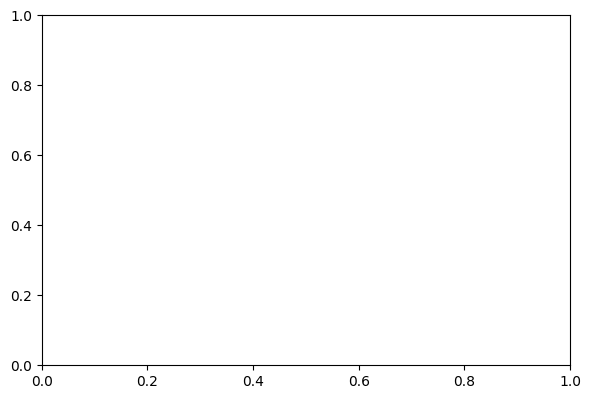

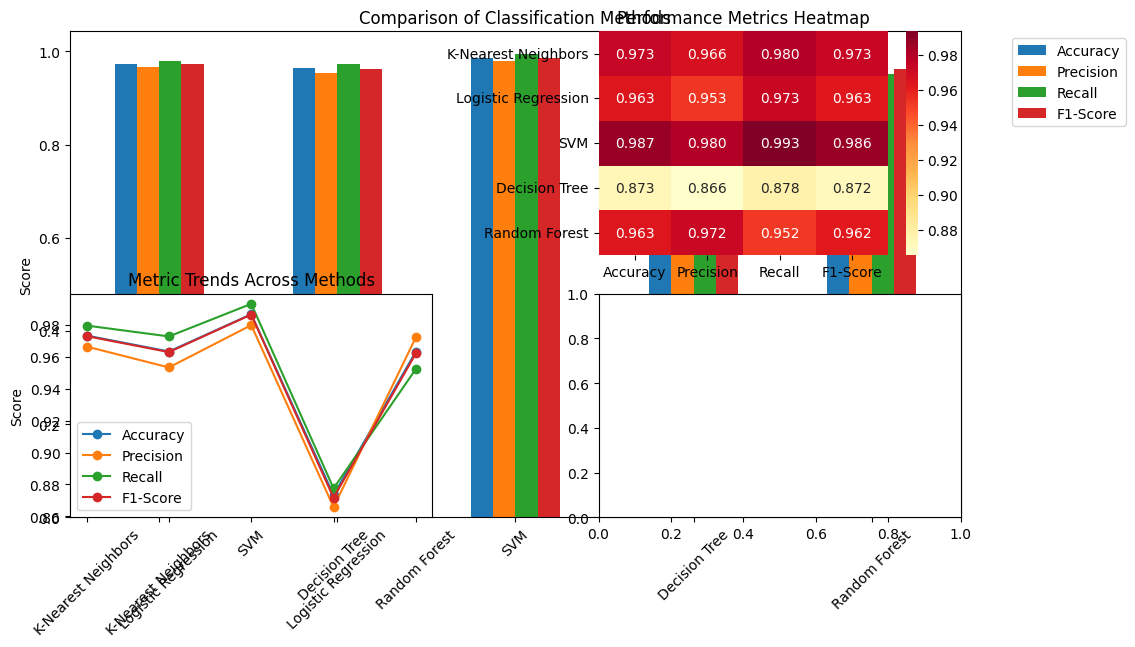

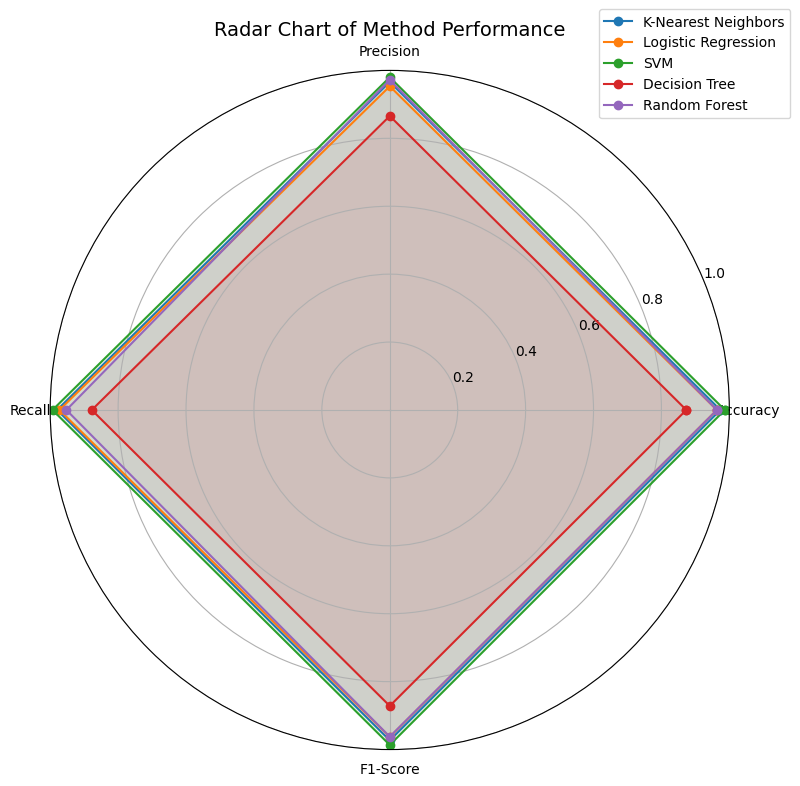

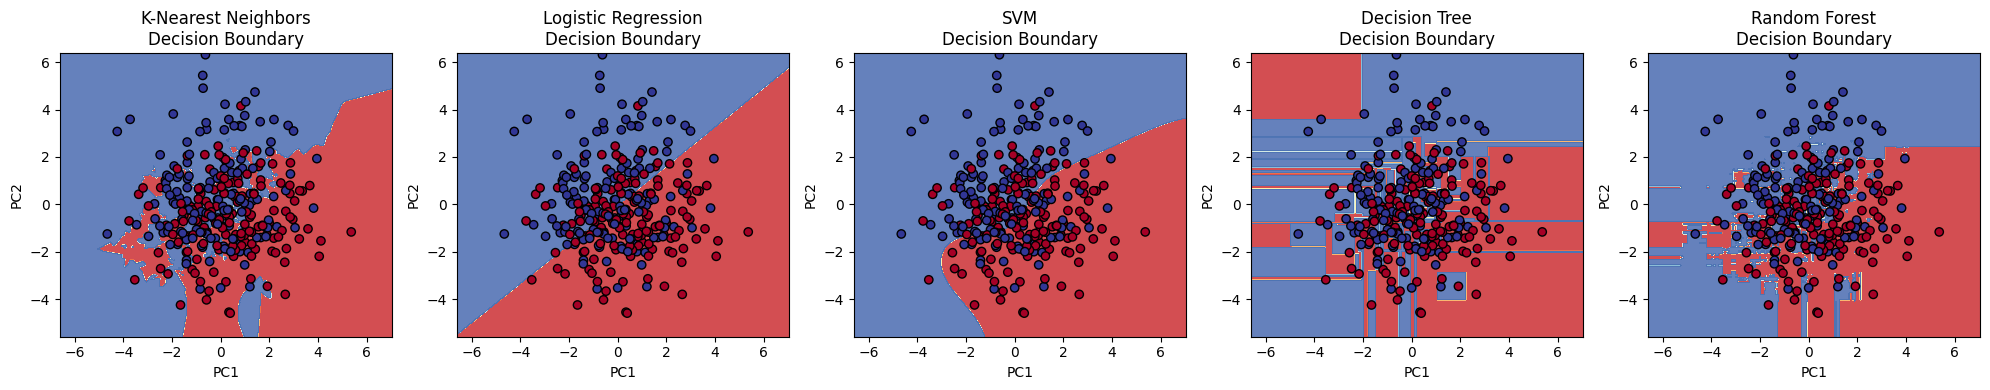


ANALYSIS AND RECOMMENDATIONS
Best Accuracy: SVM (0.9867)
Best Precision: SVM (0.9799)
Best Recall: SVM (0.9932)
Best F1-Score: SVM (0.9865)

Overall Best Method: SVM

METHOD CHARACTERISTICS AND RECOMMENDED USE CASES

K-Nearest Neighbors:
  Strengths: Simple, no training phase, good for small datasets
  Weaknesses: Computationally expensive for large datasets, sensitive to irrelevant features
  Decision Area: Local decision boundaries, instance-based learning

Logistic Regression:
  Strengths: Fast, provides probability estimates, good interpretability
  Weaknesses: Assumes linear decision boundary, sensitive to outliers
  Decision Area: Linear decision boundaries, probabilistic approach

SVM:
  Strengths: Effective in high dimensions, versatile with kernels
  Weaknesses: Memory intensive, sensitive to parameter tuning
  Decision Area: Complex non-linear boundaries, margin maximization

Decision Tree:
  Strengths: Interpretable, handles mixed data types, no feature scaling needed
  Wea

In [16]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Create a sample dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                          n_redundant=5, n_clusters_per_class=1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale the features for methods that are sensitive to feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize classifiers
classifiers = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results
results = {}

# Train and evaluate each classifier
for name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")
    
    # Use scaled data for KNN and SVM, original for others
    if name in ['K-Nearest Neighbors', 'SVM']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test
    
    # Train the model
    classifier.fit(X_tr, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_te)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    # Print detailed report
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

# Create summary table
results_df = pd.DataFrame(results).T
print(f"\n{'='*60}")
print("SUMMARY TABLE OF ALL METHODS")
print(f"{'='*60}")
print(results_df.round(4))

# Visualize the results
plt.figure(figsize=(15, 10))

# Plot 1: Bar plot of all metrics
plt.subplot(2, 2, 1)
results_df.plot(kind='bar', figsize=(12, 8))
plt.title('Comparison of Classification Methods')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Plot 2: Heatmap of results
plt.subplot(2, 2, 2)
sns.heatmap(results_df, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('Performance Metrics Heatmap')
plt.tight_layout()

# Plot 3: Individual metric comparisons
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plt.subplot(2, 2, 3)
for metric in metrics:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric)
plt.title('Metric Trends Across Methods')
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.legend()
plt.tight_layout()

# Plot 4: Radar chart for comprehensive comparison
plt.subplot(2, 2, 4)
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
for method in results_df.index:
    values = results_df.loc[method].tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', label=method)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
plt.title('Radar Chart of Method Performance', size=14)
plt.legend(bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()

plt.show()

# Decision boundary visualization (2D projection)
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

# Train on 2D data for visualization
plt.figure(figsize=(20, 4))
for i, (name, classifier) in enumerate(classifiers.items()):
    plt.subplot(1, 5, i+1)
    
    # Train on 2D data
    if name in ['K-Nearest Neighbors', 'SVM']:
        classifier.fit(X_train_2d, y_train)
    else:
        classifier.fit(X_train_2d, y_train)
    
    # Create mesh for decision boundary
    h = 0.02
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                         cmap=plt.cm.RdYlBu, edgecolors='black')
    plt.title(f'{name}\nDecision Boundary')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

plt.tight_layout()
plt.show()

# Detailed analysis and recommendations
print(f"\n{'='*60}")
print("ANALYSIS AND RECOMMENDATIONS")
print(f"{'='*60}")

# Find best method for each metric
best_methods = {}
for metric in metrics:
    best_method = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    best_methods[metric] = (best_method, best_score)
    print(f"Best {metric}: {best_method} ({best_score:.4f})")

# Overall best method
overall_best = results_df.mean(axis=1).idxmax()
print(f"\nOverall Best Method: {overall_best}")

print(f"\n{'='*60}")
print("METHOD CHARACTERISTICS AND RECOMMENDED USE CASES")
print(f"{'='*60}")

method_characteristics = {
    'K-Nearest Neighbors': {
        'strengths': 'Simple, no training phase, good for small datasets',
        'weaknesses': 'Computationally expensive for large datasets, sensitive to irrelevant features',
        'decision_area': 'Local decision boundaries, instance-based learning'
    },
    'Logistic Regression': {
        'strengths': 'Fast, provides probability estimates, good interpretability',
        'weaknesses': 'Assumes linear decision boundary, sensitive to outliers',
        'decision_area': 'Linear decision boundaries, probabilistic approach'
    },
    'SVM': {
        'strengths': 'Effective in high dimensions, versatile with kernels',
        'weaknesses': 'Memory intensive, sensitive to parameter tuning',
        'decision_area': 'Complex non-linear boundaries, margin maximization'
    },
    'Decision Tree': {
        'strengths': 'Interpretable, handles mixed data types, no feature scaling needed',
        'weaknesses': 'Prone to overfitting, unstable with small data changes',
        'decision_area': 'Hierarchical decision making, rule-based classification'
    },
    'Random Forest': {
        'strengths': 'Reduces overfitting, handles high dimensionality, robust',
        'weaknesses': 'Less interpretable, can be slow for large datasets',
        'decision_area': 'Ensemble learning, combines multiple decision trees'
    }
}

for method, chars in method_characteristics.items():
    print(f"\n{method}:")
    print(f"  Strengths: {chars['strengths']}")
    print(f"  Weaknesses: {chars['weaknesses']}")
    print(f"  Decision Area: {chars['decision_area']}")

# Create final summary table with rankings
rankings_df = results_df.rank(ascending=False).astype(int)
print(f"\n{'='*60}")
print("RANKING TABLE (1 = Best)")
print(f"{'='*60}")
print(rankings_df)

In [ ]:
#[Problem 9] (Advanced task) Comparison with and without standardization

COMPARISON WITH AND WITHOUT STANDARDIZATION

RESULTS WITHOUT STANDARDIZATION

Training K-Nearest Neighbors without standardization...
Accuracy: 0.9633, Precision: 0.9595, Recall: 0.9660, F1-Score: 0.9627

Training Logistic Regression without standardization...
Accuracy: 0.9633, Precision: 0.9533, Recall: 0.9728, F1-Score: 0.9630

Training SVM without standardization...
Accuracy: 0.9867, Precision: 0.9799, Recall: 0.9932, F1-Score: 0.9865

Training Decision Tree without standardization...
Accuracy: 0.8733, Precision: 0.8658, Recall: 0.8776, F1-Score: 0.8716

Training Random Forest without standardization...
Accuracy: 0.9633, Precision: 0.9722, Recall: 0.9524, F1-Score: 0.9622

RESULTS WITH STANDARDIZATION

Training K-Nearest Neighbors with standardization...
Accuracy: 0.9733, Precision: 0.9664, Recall: 0.9796, F1-Score: 0.9730

Training Logistic Regression with standardization...
Accuracy: 0.9633, Precision: 0.9595, Recall: 0.9660, F1-Score: 0.9627

Training SVM with standardization...


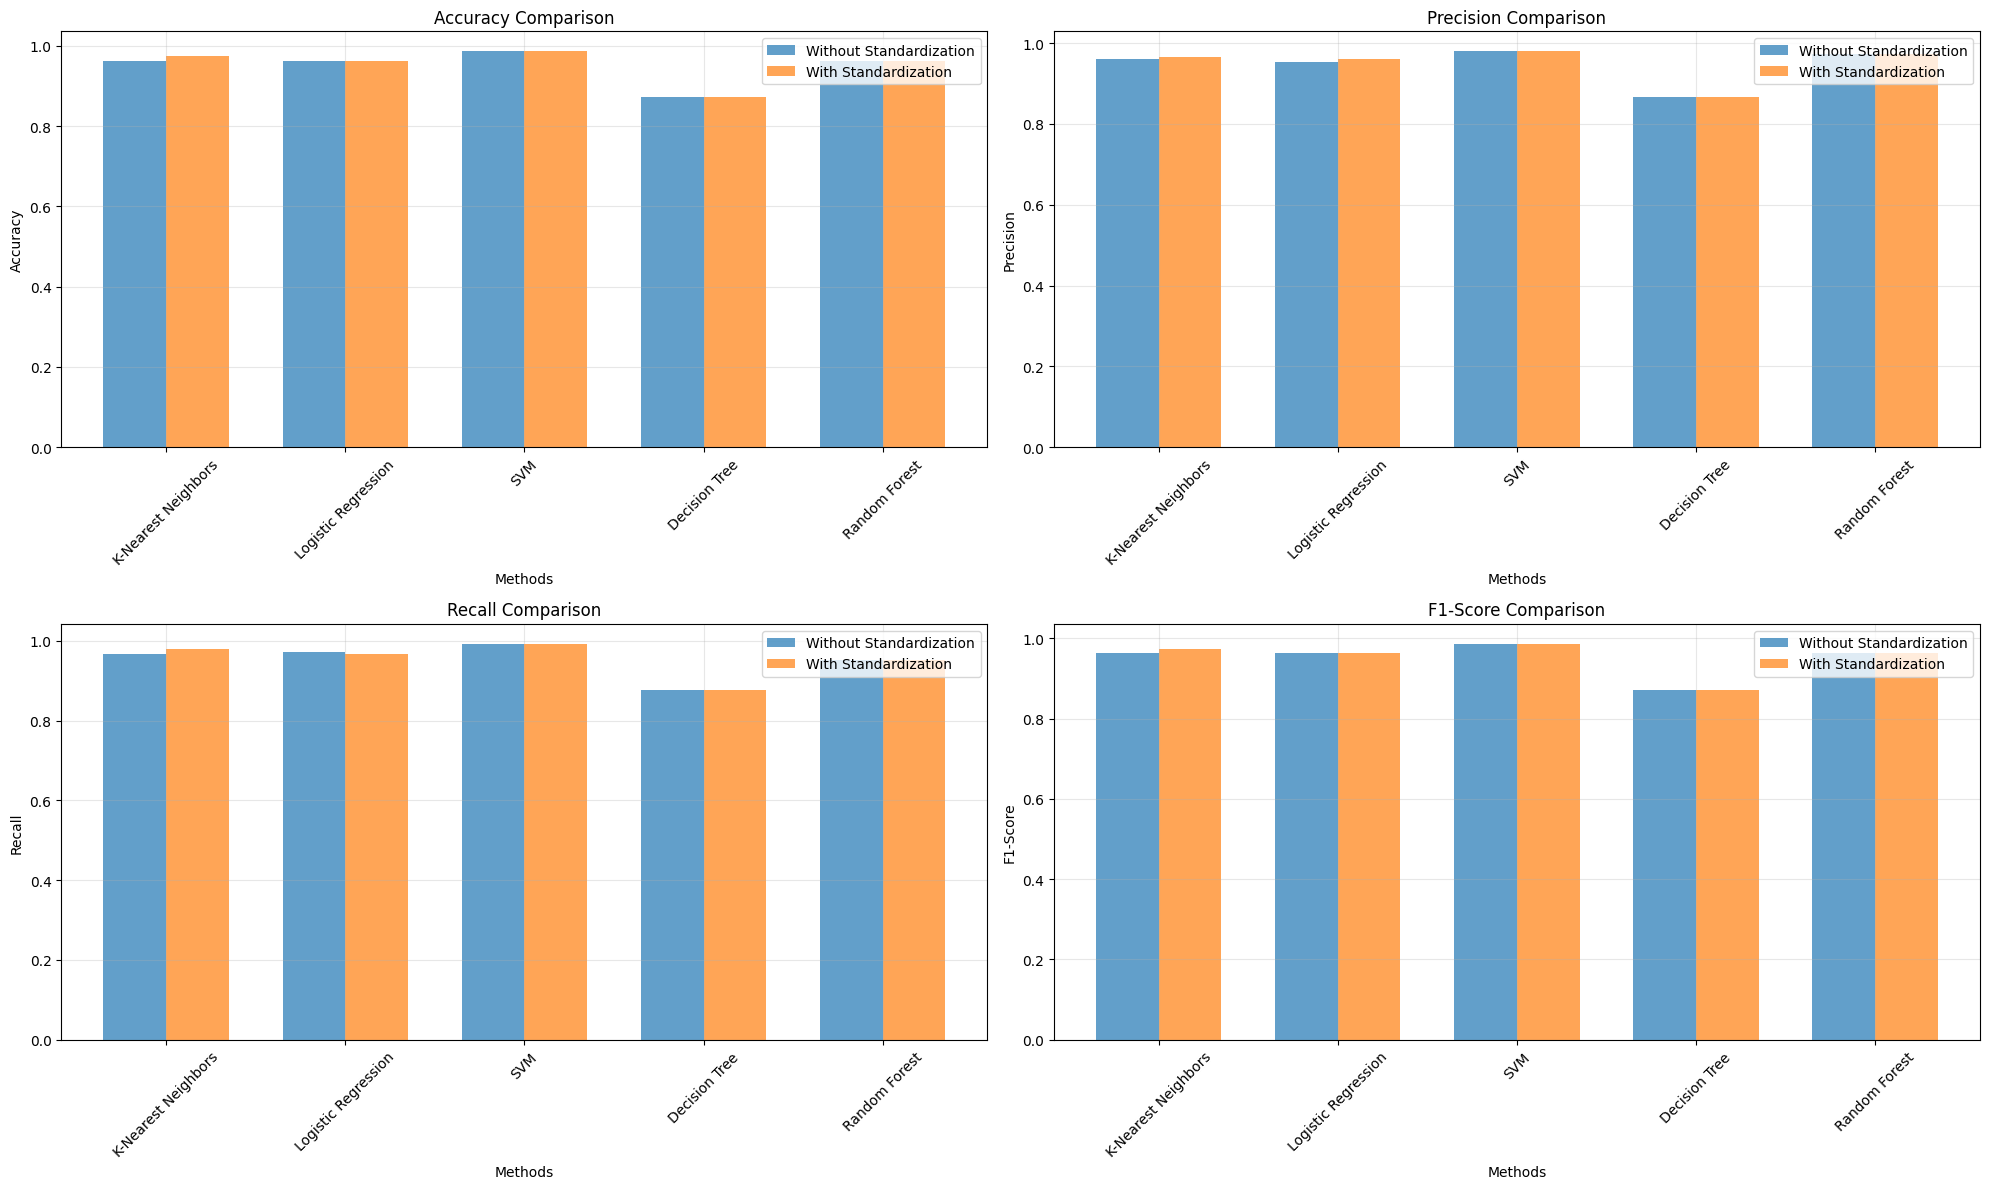

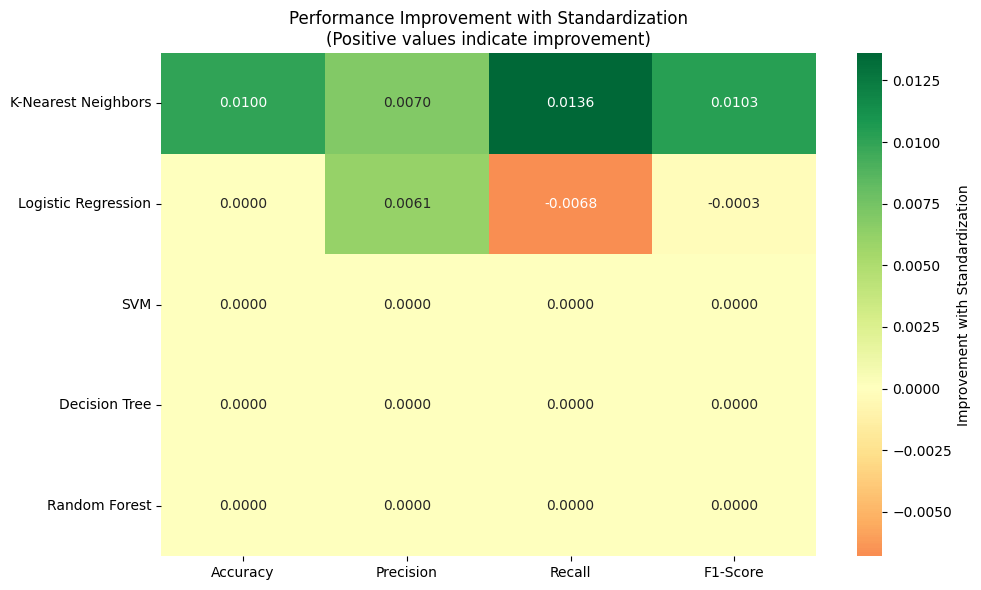

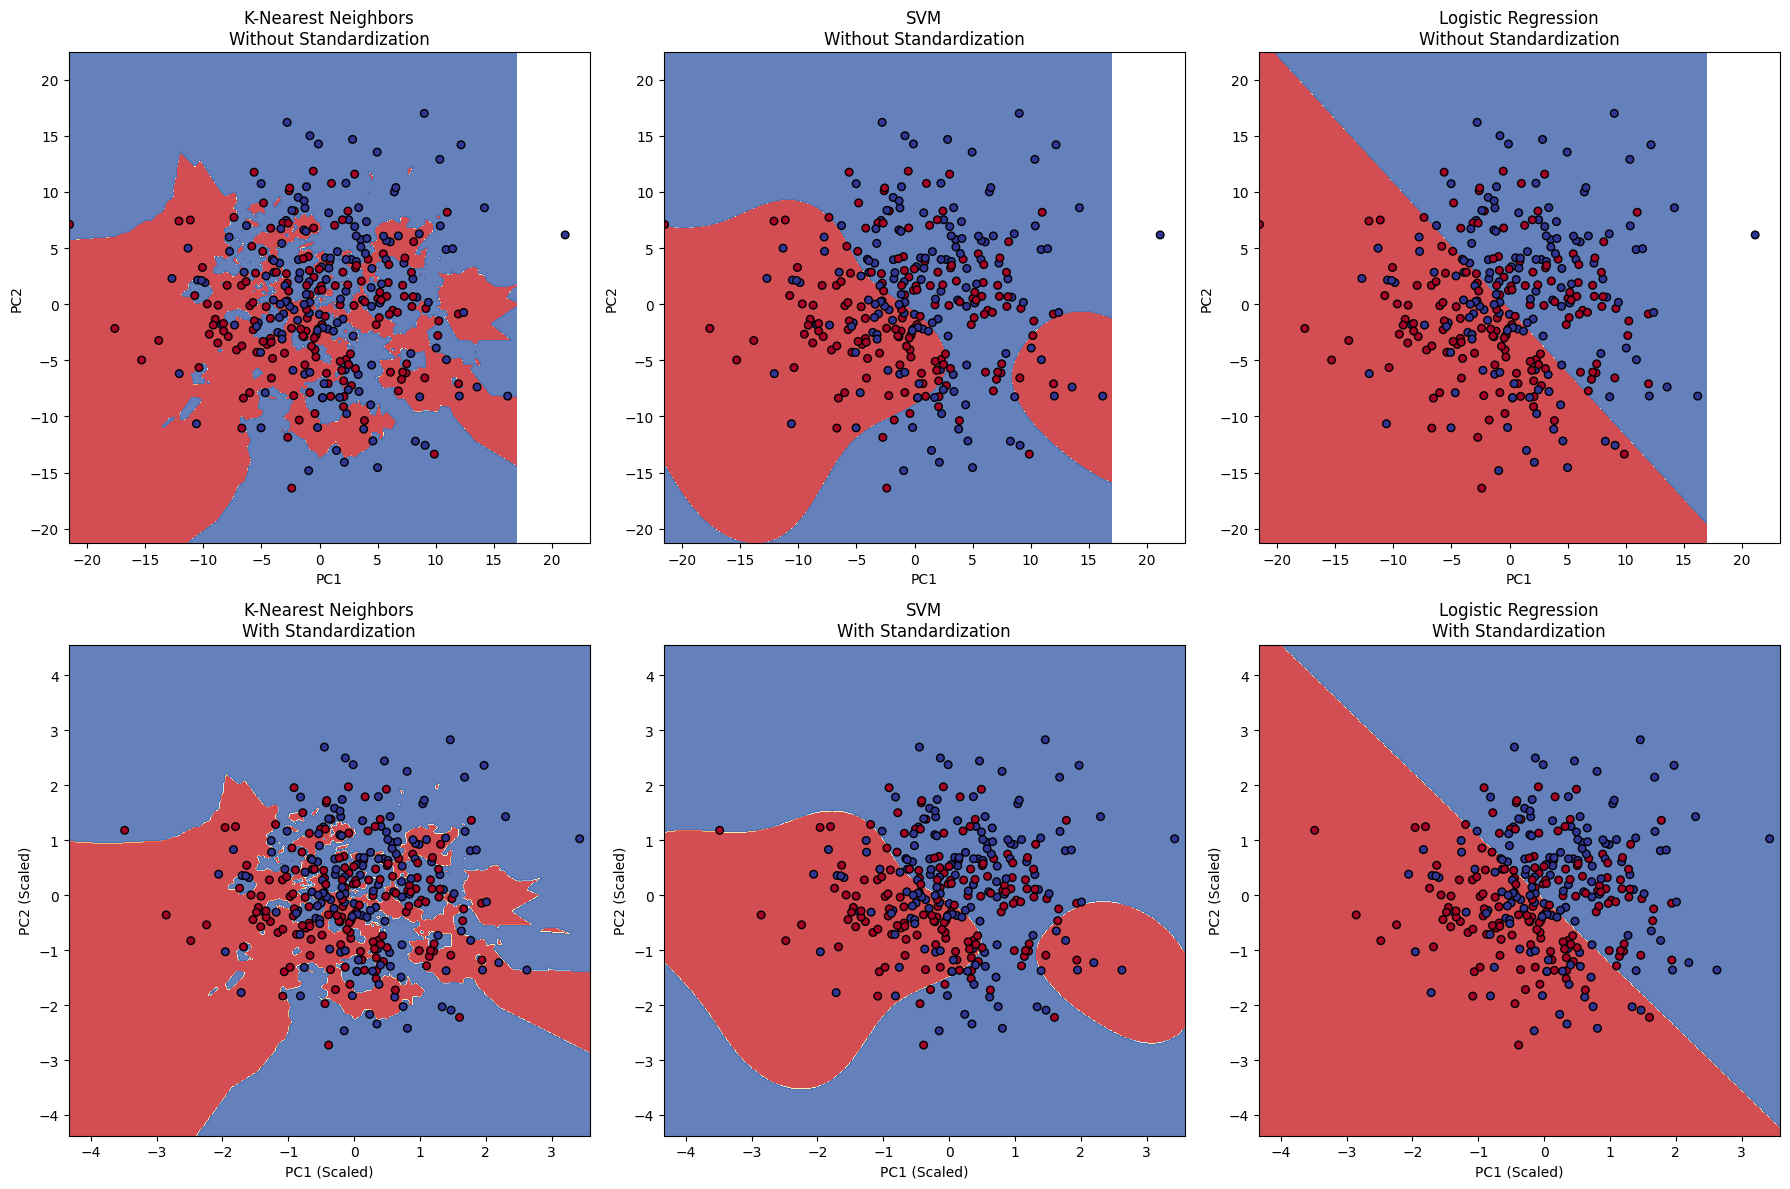

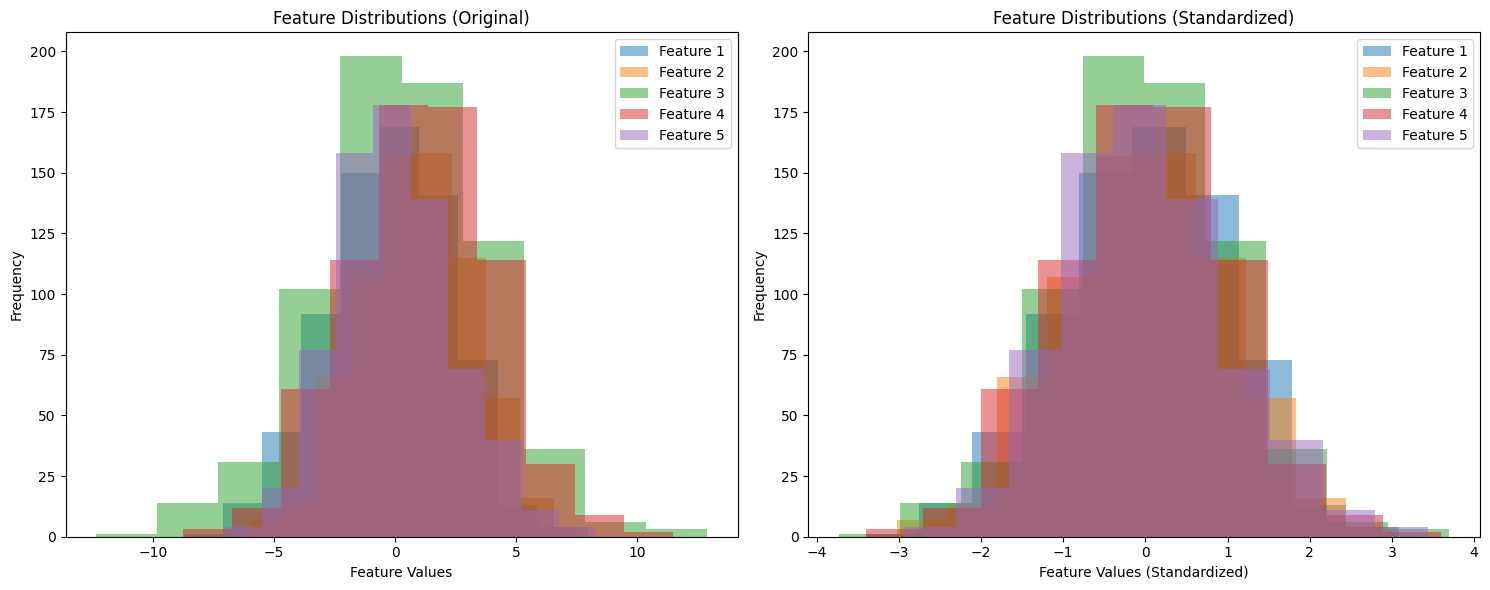


DETAILED ANALYSIS

1. WHAT IS STANDARDIZATION?
Standardization (Z-score normalization) transforms features to have:
- Mean = 0
- Standard Deviation = 1
Formula: z = (x - μ) / σ
Purpose: Ensures all features contribute equally to distance calculations

2. IMPACT ON DIFFERENT ALGORITHMS:

K-Nearest Neighbors:
  Sensitivity: High
  Reason: Uses distance metrics (Euclidean) - sensitive to feature scales
  Accuracy Improvement: 0.0100
  Explanation: Standardization ensures all features contribute equally to distance calculations

SVM:
  Sensitivity: High
  Reason: Uses distance-based kernels and margin optimization
  Accuracy Improvement: 0.0000
  Explanation: Prevents features with larger scales from dominating the optimization

Logistic Regression:
  Sensitivity: Medium-High
  Reason: Uses gradient descent optimization with regularization
  Accuracy Improvement: 0.0000
  Explanation: Helps convergence and prevents coefficient bias toward high-variance features

Decision Tree:
  Sensitivi

In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Create a sample dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                          n_redundant=5, n_clusters_per_class=1, random_state=42)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize classifiers
classifiers = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results for both cases
results_with_standardization = {}
results_without_standardization = {}

print("="*70)
print("COMPARISON WITH AND WITHOUT STANDARDIZATION")
print("="*70)

# Case 1: Without Standardization
print("\n" + "="*50)
print("RESULTS WITHOUT STANDARDIZATION")
print("="*50)

for name, classifier in classifiers.items():
    print(f"\nTraining {name} without standardization...")
    
    # Train the model
    classifier.fit(X_train, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results_without_standardization[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Case 2: With Standardization
print("\n" + "="*50)
print("RESULTS WITH STANDARDIZATION")
print("="*50)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for name, classifier in classifiers.items():
    print(f"\nTraining {name} with standardization...")
    
    # Use scaled data for all classifiers for fair comparison
    classifier.fit(X_train_scaled, y_train)
    y_pred = classifier.predict(X_test_scaled)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results_with_standardization[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# Create summary tables
df_without_std = pd.DataFrame(results_without_standardization).T
df_with_std = pd.DataFrame(results_with_standardization).T

print("\n" + "="*70)
print("COMPARISON TABLE - WITHOUT STANDARDIZATION")
print("="*70)
print(df_without_std.round(4))

print("\n" + "="*70)
print("COMPARISON TABLE - WITH STANDARDIZATION")
print("="*70)
print(df_with_std.round(4))

# Calculate differences
difference_df = df_with_std - df_without_std
print("\n" + "="*70)
print("DIFFERENCE (With Standardization - Without Standardization)")
print("="*70)
print(difference_df.round(4))

# Visualize the comparison
plt.figure(figsize=(20, 12))

# Plot 1: Side-by-side comparison for each metric
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Get values for both cases
    without_std = df_without_std[metric]
    with_std = df_with_std[metric]
    
    x = np.arange(len(classifiers))
    width = 0.35
    
    plt.bar(x - width/2, without_std, width, label='Without Standardization', alpha=0.7)
    plt.bar(x + width/2, with_std, width, label='With Standardization', alpha=0.7)
    
    plt.xlabel('Methods')
    plt.ylabel(metric)
    plt.title(f'{metric} Comparison')
    plt.xticks(x, list(classifiers.keys()), rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Plot 2: Improvement heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(difference_df, annot=True, cmap='RdYlGn', center=0, fmt='.4f',
            cbar_kws={'label': 'Improvement with Standardization'})
plt.title('Performance Improvement with Standardization\n(Positive values indicate improvement)')
plt.tight_layout()
plt.show()

# Plot 3: Decision boundaries comparison (2D projection)
# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Scale the 2D data for standardized case
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Select a subset of classifiers for clearer visualization
selected_classifiers = ['K-Nearest Neighbors', 'SVM', 'Logistic Regression']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, name in enumerate(selected_classifiers):
    # Without standardization
    ax1 = axes[0, col]
    classifier = classifiers[name]
    classifier.fit(X_train_2d, y_train)
    
    # Create mesh for decision boundary
    h = 0.02
    x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
    y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax1.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    scatter1 = ax1.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, 
                          cmap=plt.cm.RdYlBu, edgecolors='black', s=30)
    ax1.set_title(f'{name}\nWithout Standardization')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    
    # With standardization
    ax2 = axes[1, col]
    classifier = classifiers[name]
    classifier.fit(X_train_2d_scaled, y_train)
    
    # Create mesh for scaled data
    x_min, x_max = X_train_2d_scaled[:, 0].min() - 1, X_train_2d_scaled[:, 0].max() + 1
    y_min, y_max = X_train_2d_scaled[:, 1].min() - 1, X_train_2d_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax2.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    scatter2 = ax2.scatter(X_test_2d_scaled[:, 0], X_test_2d_scaled[:, 1], c=y_test, 
                          cmap=plt.cm.RdYlBu, edgecolors='black', s=30)
    ax2.set_title(f'{name}\nWith Standardization')
    ax2.set_xlabel('PC1 (Scaled)')
    ax2.set_ylabel('PC2 (Scaled)')

plt.tight_layout()
plt.show()

# Feature distribution comparison
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
# Plot original feature distributions (first 5 features)
for i in range(5):
    plt.hist(X_train[:, i], alpha=0.5, label=f'Feature {i+1}')
plt.title('Feature Distributions (Original)')
plt.xlabel('Feature Values')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
# Plot standardized feature distributions
for i in range(5):
    plt.hist(X_train_scaled[:, i], alpha=0.5, label=f'Feature {i+1}')
plt.title('Feature Distributions (Standardized)')
plt.xlabel('Feature Values (Standardized)')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

# Detailed analysis
print("\n" + "="*70)
print("DETAILED ANALYSIS")
print("="*70)

print("\n1. WHAT IS STANDARDIZATION?")
print("Standardization (Z-score normalization) transforms features to have:")
print("- Mean = 0")
print("- Standard Deviation = 1")
print("Formula: z = (x - μ) / σ")
print("Purpose: Ensures all features contribute equally to distance calculations")

print("\n2. IMPACT ON DIFFERENT ALGORITHMS:")

algorithm_sensitivity = {
    'K-Nearest Neighbors': {
        'sensitivity': 'High',
        'reason': 'Uses distance metrics (Euclidean) - sensitive to feature scales',
        'improvement': f"{difference_df.loc['K-Nearest Neighbors', 'Accuracy']:.4f}",
        'explanation': 'Standardization ensures all features contribute equally to distance calculations'
    },
    'SVM': {
        'sensitivity': 'High', 
        'reason': 'Uses distance-based kernels and margin optimization',
        'improvement': f"{difference_df.loc['SVM', 'Accuracy']:.4f}",
        'explanation': 'Prevents features with larger scales from dominating the optimization'
    },
    'Logistic Regression': {
        'sensitivity': 'Medium-High',
        'reason': 'Uses gradient descent optimization with regularization',
        'improvement': f"{difference_df.loc['Logistic Regression', 'Accuracy']:.4f}",
        'explanation': 'Helps convergence and prevents coefficient bias toward high-variance features'
    },
    'Decision Tree': {
        'sensitivity': 'None',
        'reason': 'Makes splits based on feature value ordering, not absolute values',
        'improvement': f"{difference_df.loc['Decision Tree', 'Accuracy']:.4f}",
        'explanation': 'Tree-based algorithms are invariant to feature scaling'
    },
    'Random Forest': {
        'sensitivity': 'None',
        'reason': 'Ensemble of Decision Trees - inherits scale invariance',
        'improvement': f"{difference_df.loc['Random Forest', 'Accuracy']:.4f}",
        'explanation': 'As an ensemble of trees, it remains unaffected by feature scaling'
    }
}

for method, info in algorithm_sensitivity.items():
    print(f"\n{method}:")
    print(f"  Sensitivity: {info['sensitivity']}")
    print(f"  Reason: {info['reason']}")
    print(f"  Accuracy Improvement: {info['improvement']}")
    print(f"  Explanation: {info['explanation']}")

print("\n3. KEY OBSERVATIONS:")
print("• Distance-based algorithms (KNN, SVM) benefit most from standardization")
print("• Tree-based algorithms are largely unaffected by standardization")  
print("• Standardization improves model convergence and stability")
print("• It prevents feature dominance and makes models more interpretable")

print("\n4. RECOMMENDATIONS:")
print("• Always standardize for: KNN, SVM, Neural Networks, PCA, LDA")
print("• Optional for: Logistic Regression (but recommended for better performance)")
print("• Not needed for: Decision Trees, Random Forests, Gradient Boosting")
print("• When in doubt: Standardize - it rarely hurts and often helps")

In [ ]:
#[Problem 10] (Advance assignment) Highly accurate method using all objective variables

IRIS DATASET - MULTI-CLASS CLASSIFICATION
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class distribution: [50 50 50]

Training set size: 105
Test set size: 45
Training set class distribution: [35 35 35]
Test set class distribution: [15 15 15]

TRAINING AND EVALUATION RESULTS

Training K-Nearest Neighbors
Accuracy: 0.9111
Precision (Macro): 0.9298
Recall (Macro): 0.9111
F1-Score (Macro): 0.9095
Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]

Training Logistic Regression
Accuracy: 0.9111
Precision (Macro): 0.9155
Recall (Macro): 0.9111
F1-Score (Macro): 0.9107
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Training SVM
Accuracy: 0.9333
Precision (Macro): 0.9345
Recall (Macro): 0.9333
F1-Score (Macro): 0.9333
Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  2 13]]

Training Decision Tree
Accuracy: 0.9333
Precision (Macro): 0.944

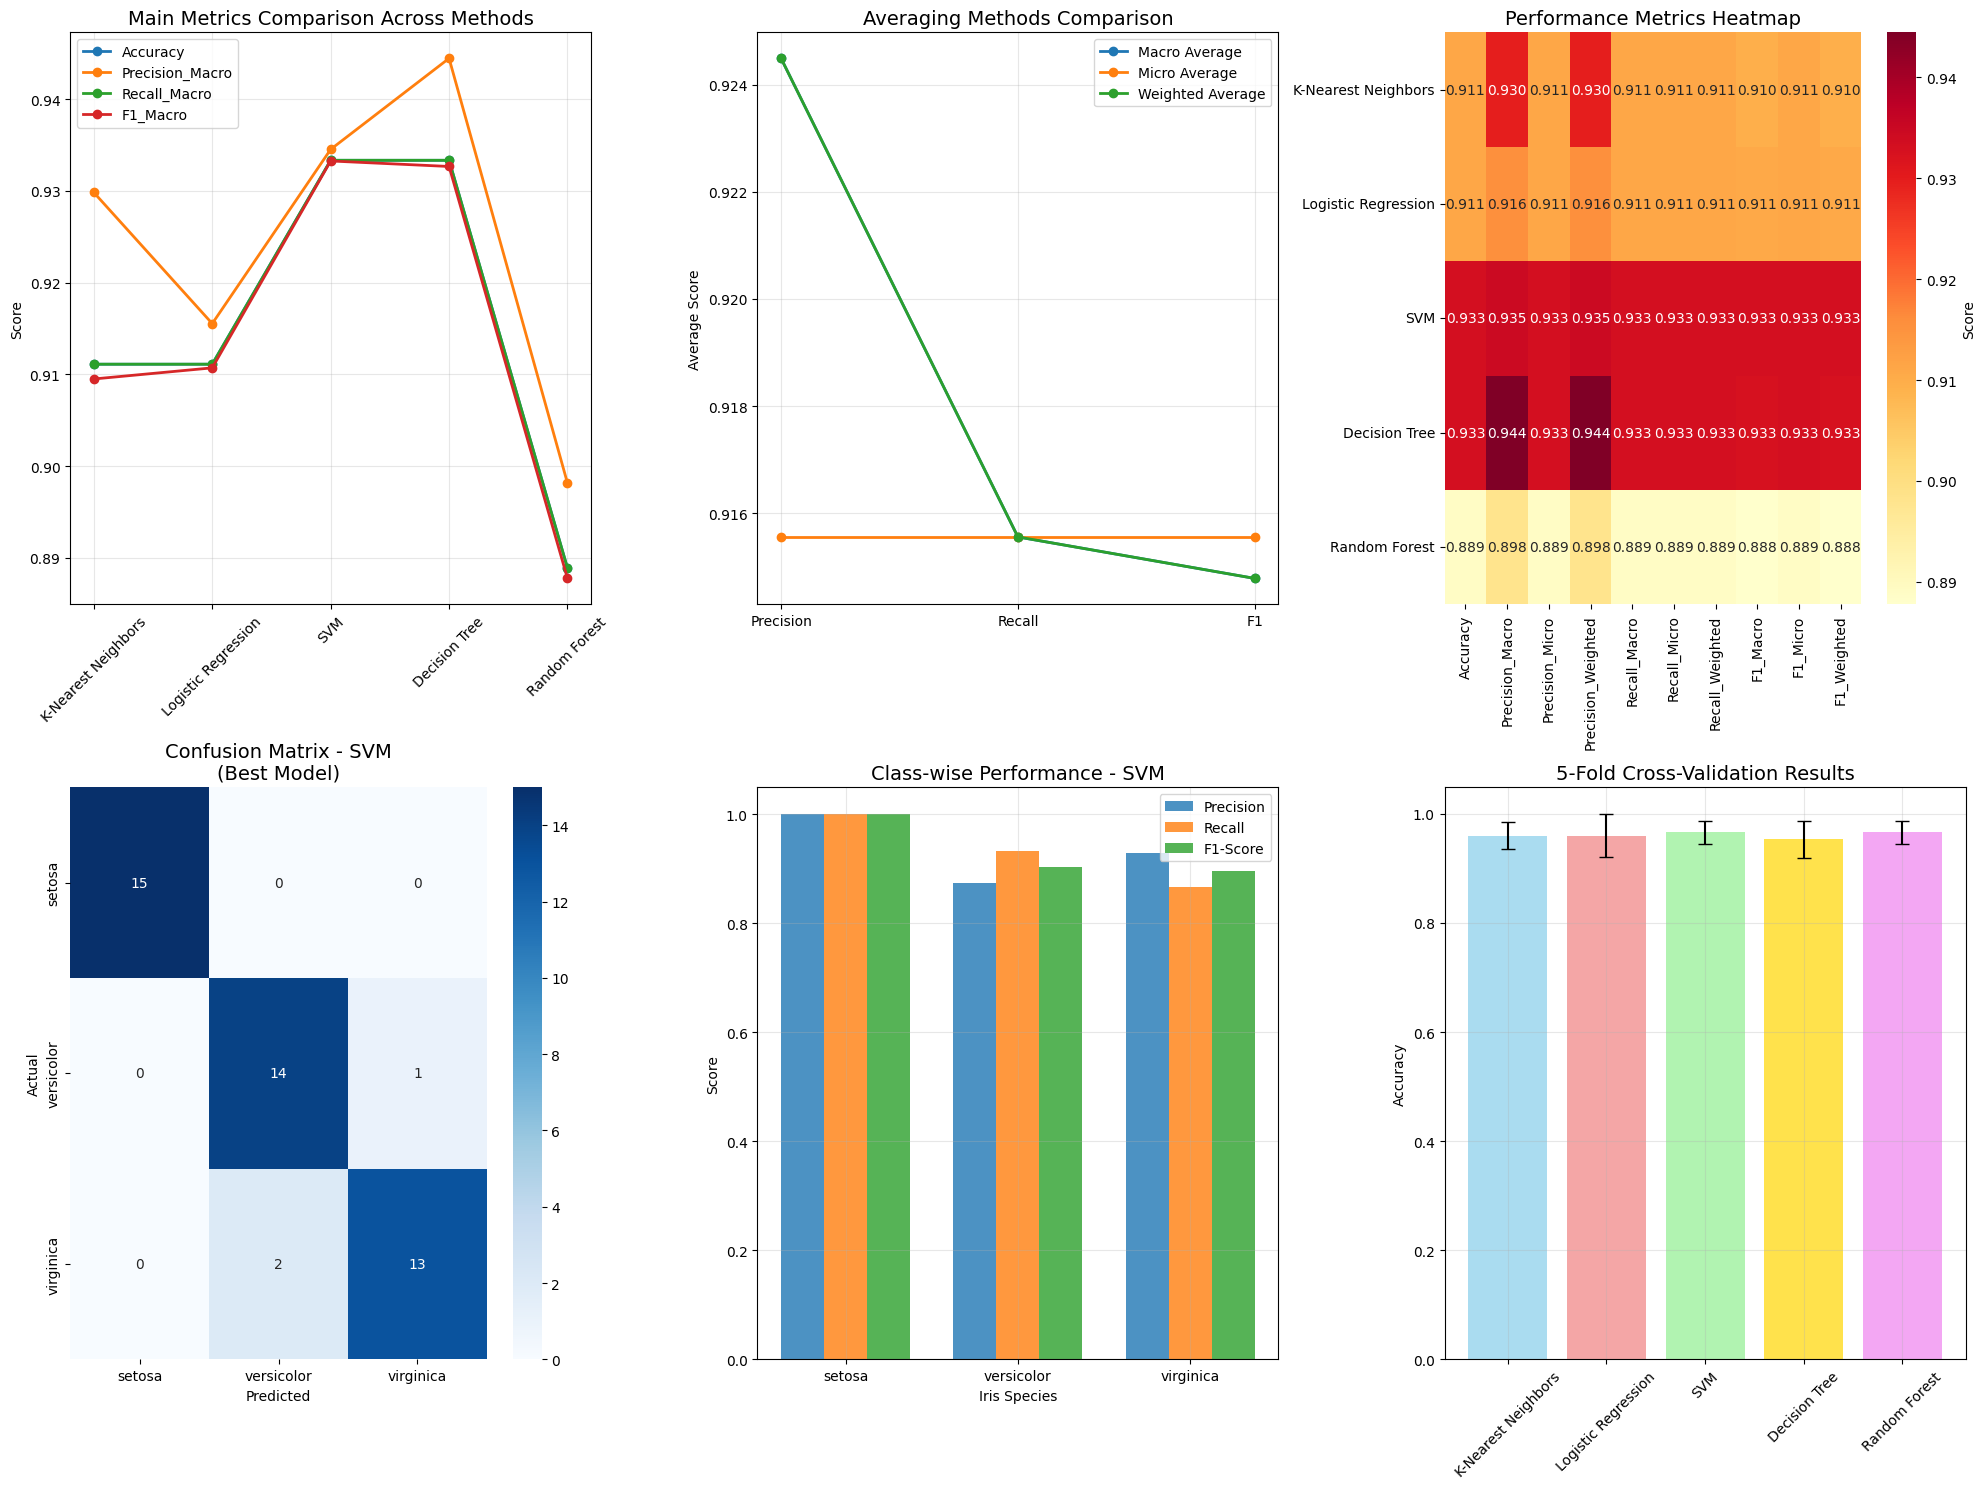


DECISION BOUNDARY VISUALIZATION
Using first two features: Sepal Length vs Sepal Width


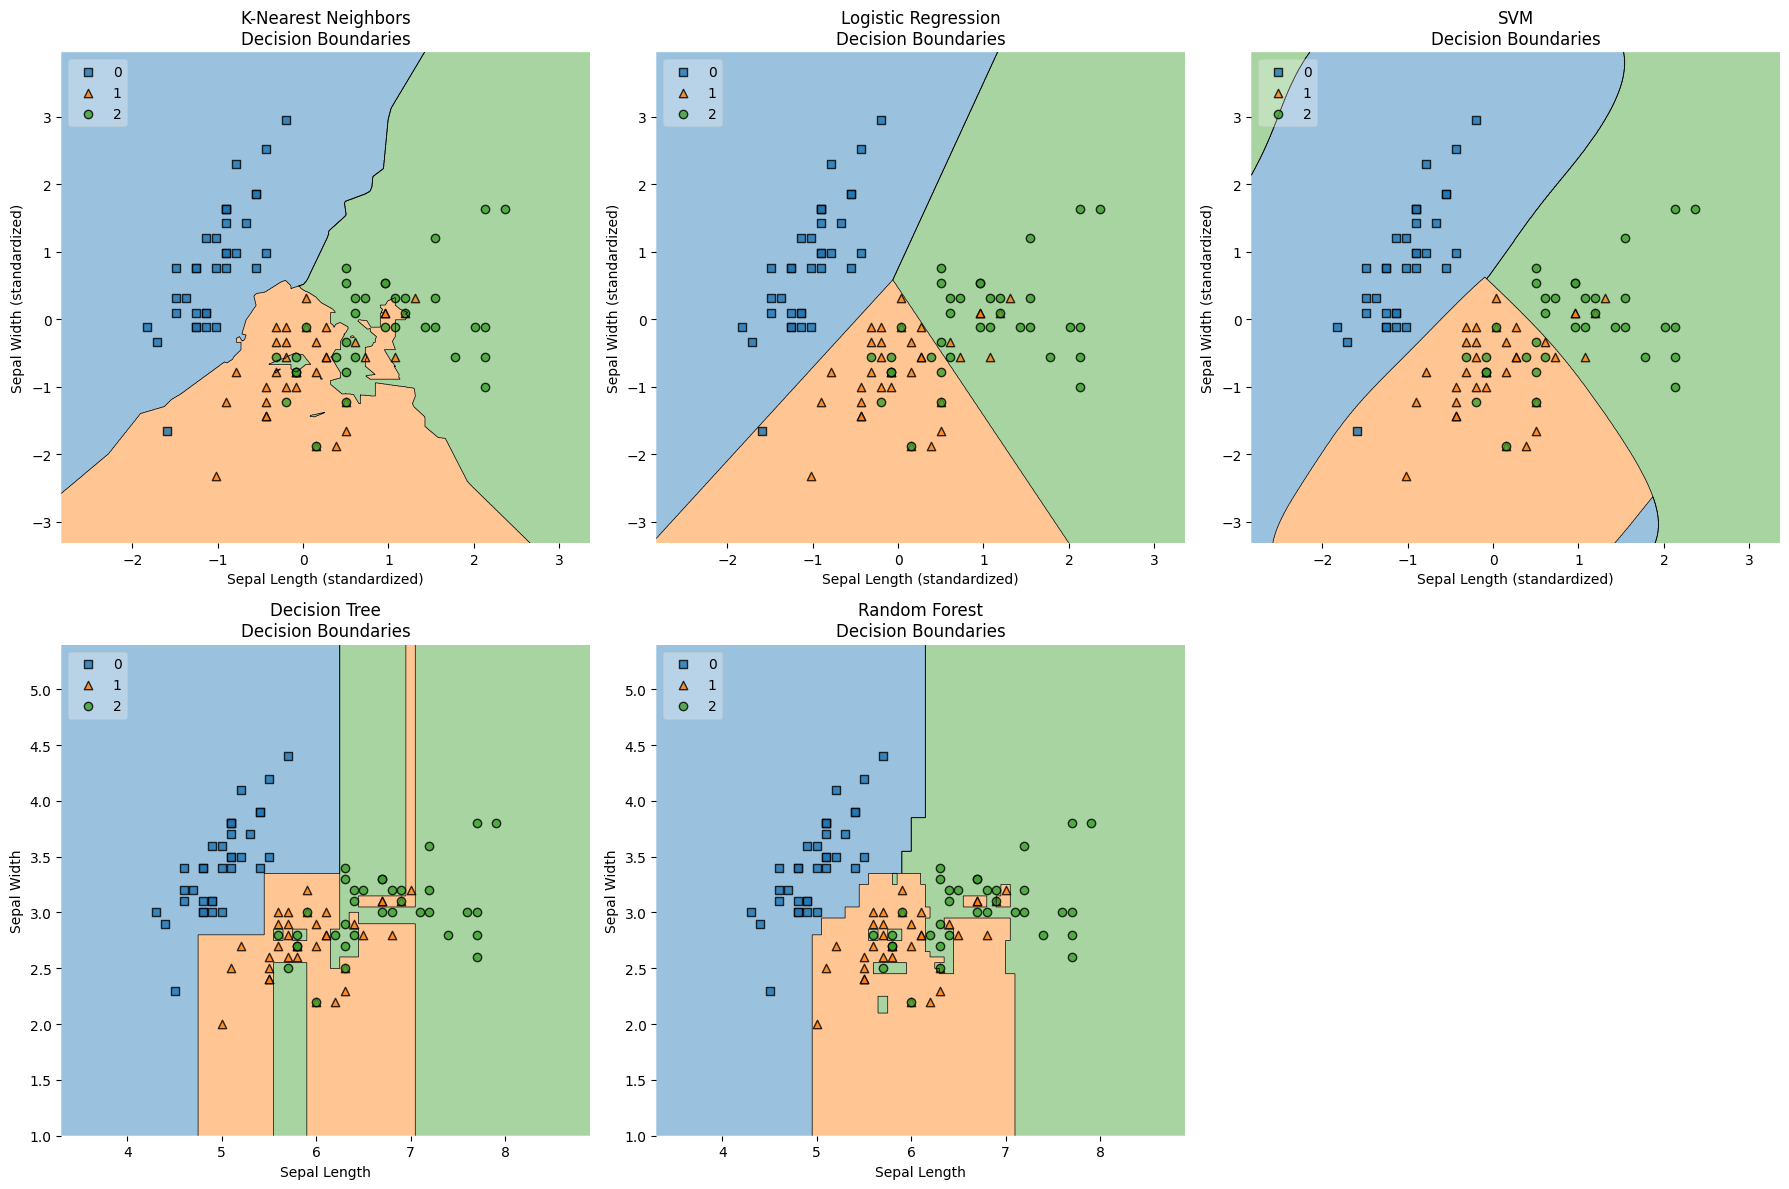


FEATURE IMPORTANCE ANALYSIS


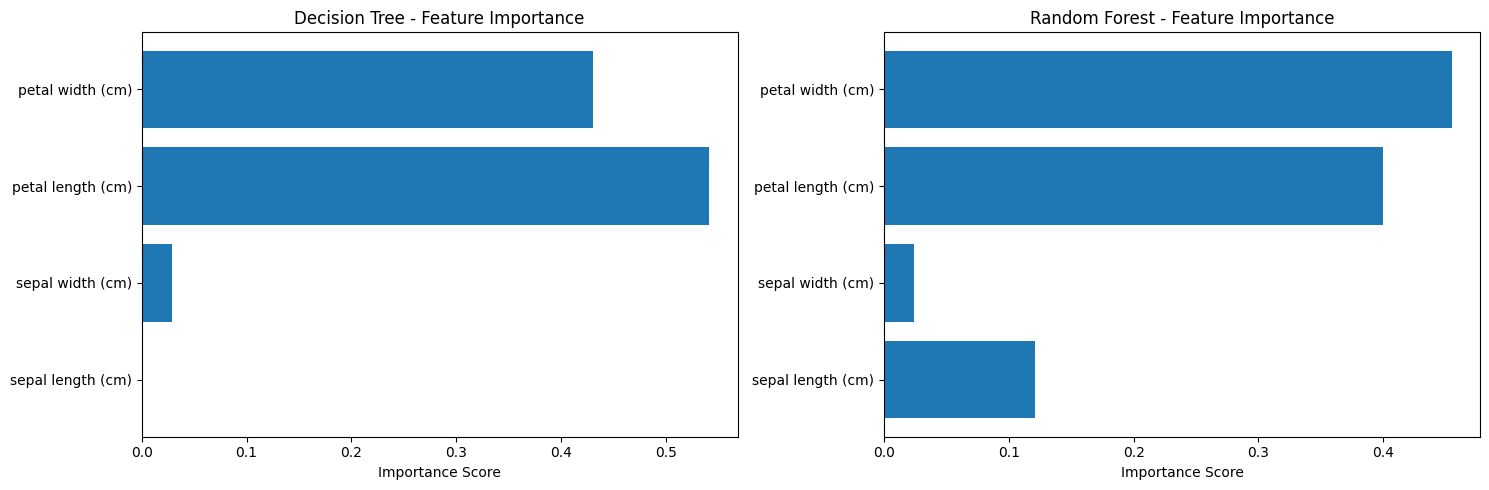


DETAILED ANALYSIS AND RECOMMENDATIONS

BEST METHODS FOR EACH METRIC:
Accuracy: SVM (0.9333)
Precision_Macro: Decision Tree (0.9444)
Recall_Macro: SVM (0.9333)
F1_Macro: SVM (0.9333)

OVERALL BEST METHOD: SVM (Accuracy: 0.9333)

UNDERSTANDING AVERAGING METHODS:
Macro-average: Compute metric for each class, then average (treats all classes equally)
Micro-average: Aggregate contributions of all classes (favors larger classes)
Weighted-average: Average weighted by support (number of true instances for each class)

METHOD CHARACTERISTICS FOR MULTI-CLASS CLASSIFICATION:

K-Nearest Neighbors:
  Multi-class strategy: Uses one-vs-all approach internally
  Strengths: Simple, no assumptions about data distribution
  Best for: Small to medium datasets, when decision boundary is irregular

Logistic Regression:
  Multi-class strategy: One-vs-rest (OvR) by default, can use multinomial
  Strengths: Provides probability estimates, fast training
  Best for: When probability estimates are needed, linear

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions

# Load the iris dataset
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print("="*70)
print("IRIS DATASET - MULTI-CLASS CLASSIFICATION")
print("="*70)
print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {list(target_names)}")
print(f"Class distribution: {np.bincount(y)}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set class distribution: {np.bincount(y_train)}")
print(f"Test set class distribution: {np.bincount(y_test)}")

# Initialize classifiers
classifiers = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Dictionary to store results
results = {}
detailed_reports = {}

print("\n" + "="*70)
print("TRAINING AND EVALUATION RESULTS")
print("="*70)

# Train and evaluate each classifier
for name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")
    
    # Use scaled data for distance-based algorithms
    if name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test
    
    # Train the model
    classifier.fit(X_tr, y_train)
    
    # Make predictions
    y_pred = classifier.predict(X_te)
    y_pred_proba = classifier.predict_proba(X_te) if hasattr(classifier, 'predict_proba') else None
    
    # Calculate metrics with different averaging methods
    accuracy = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    precision_micro = precision_score(y_test, y_pred, average='micro', zero_division=0)
    precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    recall_micro = recall_score(y_test, y_pred, average='micro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision_Macro': precision_macro,
        'Precision_Micro': precision_micro,
        'Precision_Weighted': precision_weighted,
        'Recall_Macro': recall_macro,
        'Recall_Micro': recall_micro,
        'Recall_Weighted': recall_weighted,
        'F1_Macro': f1_macro,
        'F1_Micro': f1_micro,
        'F1_Weighted': f1_weighted
    }
    
    # Store detailed report
    detailed_reports[name] = classification_report(y_test, y_pred, 
                                                  target_names=target_names, output_dict=True)
    
    # Print results
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (Macro): {precision_macro:.4f}")
    print(f"Recall (Macro): {recall_macro:.4f}")
    print(f"F1-Score (Macro): {f1_macro:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

# Create summary table
results_df = pd.DataFrame(results).T

print("\n" + "="*70)
print("COMPREHENSIVE RESULTS SUMMARY")
print("="*70)
print(results_df.round(4))

# Cross-validation for more robust evaluation
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (5-fold)")
print("="*70)

cv_results = {}
for name, classifier in classifiers.items():
    if name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression']:
        X_cv = scaler.fit_transform(X)
    else:
        X_cv = X
    
    cv_scores = cross_val_score(classifier, X_cv, y, cv=5, scoring='accuracy')
    cv_results[name] = {
        'CV_Mean_Accuracy': cv_scores.mean(),
        'CV_Std_Accuracy': cv_scores.std(),
        'CV_Min_Accuracy': cv_scores.min(),
        'CV_Max_Accuracy': cv_scores.max()
    }
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

cv_df = pd.DataFrame(cv_results).T
print(f"\nBest CV Performance: {cv_df['CV_Mean_Accuracy'].idxmax()} "
      f"({cv_df['CV_Mean_Accuracy'].max():.4f})")

# Visualizations
plt.figure(figsize=(20, 15))

# Plot 1: Main metrics comparison
plt.subplot(2, 3, 1)
main_metrics = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
for metric in main_metrics:
    plt.plot(results_df.index, results_df[metric], marker='o', label=metric, linewidth=2)
plt.title('Main Metrics Comparison Across Methods', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Averaging methods comparison for each classifier
averaging_types = ['Macro', 'Micro', 'Weighted']
metrics = ['Precision', 'Recall', 'F1']

plt.subplot(2, 3, 2)
for avg_type in averaging_types:
    scores = [results_df[f'{metric}_{avg_type}'].mean() for metric in metrics]
    plt.plot(metrics, scores, marker='o', label=f'{avg_type} Average', linewidth=2)
plt.title('Averaging Methods Comparison', fontsize=14)
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Heatmap of all metrics
plt.subplot(2, 3, 3)
sns.heatmap(results_df, annot=True, cmap='YlOrRd', fmt='.3f', cbar_kws={'label': 'Score'})
plt.title('Performance Metrics Heatmap', fontsize=14)
plt.tight_layout()

# Plot 4: Confusion matrices
plt.subplot(2, 3, 4)
# Re-create predictions for the best model for confusion matrix
best_model_name = results_df['Accuracy'].idxmax()
best_model = classifiers[best_model_name]
if best_model_name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression']:
    best_model.fit(X_train_scaled, y_train)
    y_pred_best = best_model.predict(X_test_scaled)
else:
    best_model.fit(X_train, y_train)
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title(f'Confusion Matrix - {best_model_name}\n(Best Model)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 5: Class-wise performance for best model
plt.subplot(2, 3, 5)
class_report = detailed_reports[best_model_name]
class_metrics = []
for class_name in target_names:
    class_data = class_report[class_name]
    class_metrics.append([class_data['precision'], class_data['recall'], class_data['f1-score']])

class_metrics = np.array(class_metrics)
x = np.arange(len(target_names))
width = 0.25

plt.bar(x - width, class_metrics[:, 0], width, label='Precision', alpha=0.8)
plt.bar(x, class_metrics[:, 1], width, label='Recall', alpha=0.8)
plt.bar(x + width, class_metrics[:, 2], width, label='F1-Score', alpha=0.8)

plt.xlabel('Iris Species')
plt.ylabel('Score')
plt.title(f'Class-wise Performance - {best_model_name}', fontsize=14)
plt.xticks(x, target_names)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Cross-validation results
plt.subplot(2, 3, 6)
cv_means = [cv_results[name]['CV_Mean_Accuracy'] for name in classifiers.keys()]
cv_stds = [cv_results[name]['CV_Std_Accuracy'] for name in classifiers.keys()]

plt.bar(range(len(classifiers)), cv_means, yerr=cv_stds, capsize=5, alpha=0.7,
        color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])
plt.xticks(range(len(classifiers)), list(classifiers.keys()), rotation=45)
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Results', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Decision Boundary Visualization (using first two features)
print("\n" + "="*70)
print("DECISION BOUNDARY VISUALIZATION")
print("="*70)
print("Using first two features: Sepal Length vs Sepal Width")

# Use only first two features for 2D visualization
X_2d = X[:, :2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.3, random_state=42, stratify=y)

# Scale the 2D data
scaler_2d = StandardScaler()
X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Visualize decision boundaries
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, classifier) in enumerate(classifiers.items()):
    # Train on 2D data
    if name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression']:
        classifier.fit(X_train_2d_scaled, y_train_2d)
        X_vis = X_train_2d_scaled
    else:
        classifier.fit(X_train_2d, y_train_2d)
        X_vis = X_train_2d
    
    # Create decision boundary plot
    plot_decision_regions(X_vis, y_train_2d, clf=classifier, legend=2, ax=axes[idx])
    axes[idx].set_title(f'{name}\nDecision Boundaries', fontsize=12)
    axes[idx].set_xlabel('Sepal Length (standardized)' if name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression'] else 'Sepal Length')
    axes[idx].set_ylabel('Sepal Width (standardized)' if name in ['K-Nearest Neighbors', 'SVM', 'Logistic Regression'] else 'Sepal Width')

# Remove empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# Feature importance analysis (for tree-based methods)
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

plt.figure(figsize=(15, 5))

# Decision Tree feature importance
plt.subplot(1, 2, 1)
dt = classifiers['Decision Tree']
dt.fit(X_train, y_train)
importance_dt = dt.feature_importances_
plt.barh(feature_names, importance_dt)
plt.title('Decision Tree - Feature Importance')
plt.xlabel('Importance Score')

# Random Forest feature importance
plt.subplot(1, 2, 2)
rf = classifiers['Random Forest']
rf.fit(X_train, y_train)
importance_rf = rf.feature_importances_
plt.barh(feature_names, importance_rf)
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.show()

# Detailed analysis and recommendations
print("\n" + "="*70)
print("DETAILED ANALYSIS AND RECOMMENDATIONS")
print("="*70)

# Find best method for each metric
metrics_to_compare = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro']
best_methods = {}

print("\nBEST METHODS FOR EACH METRIC:")
for metric in metrics_to_compare:
    best_method = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    best_methods[metric] = (best_method, best_score)
    print(f"{metric}: {best_method} ({best_score:.4f})")

# Overall best method
overall_best = results_df['Accuracy'].idxmax()
overall_score = results_df['Accuracy'].max()
print(f"\nOVERALL BEST METHOD: {overall_best} (Accuracy: {overall_score:.4f})")

# Understanding averaging methods
print(f"\nUNDERSTANDING AVERAGING METHODS:")
print("Macro-average: Compute metric for each class, then average (treats all classes equally)")
print("Micro-average: Aggregate contributions of all classes (favors larger classes)")
print("Weighted-average: Average weighted by support (number of true instances for each class)")

# Method characteristics for multi-class classification
method_characters = {
    'K-Nearest Neighbors': {
        'multi_class_strategy': 'Uses one-vs-all approach internally',
        'strengths': 'Simple, no assumptions about data distribution',
        'best_for': 'Small to medium datasets, when decision boundary is irregular'
    },
    'Logistic Regression': {
        'multi_class_strategy': 'One-vs-rest (OvR) by default, can use multinomial',
        'strengths': 'Provides probability estimates, fast training',
        'best_for': 'When probability estimates are needed, linear separability'
    },
    'SVM': {
        'multi_class_strategy': 'One-vs-one (OvO) by default',
        'strengths': 'Effective in high dimensions, handles non-linear boundaries',
        'best_for': 'Complex boundaries, clear margin of separation'
    },
    'Decision Tree': {
        'multi_class_strategy': 'Native multi-class support',
        'strengths': 'Interpretable, handles mixed data types',
        'best_for': 'Interpretability, non-linear relationships'
    },
    'Random Forest': {
        'multi_class_strategy': 'Native multi-class support (ensemble of trees)',
        'strengths': 'Reduces overfitting, handles high dimensionality',
        'best_for': 'High accuracy, robust performance'
    }
}

print(f"\nMETHOD CHARACTERISTICS FOR MULTI-CLASS CLASSIFICATION:")
for method, chars in method_characters.items():
    print(f"\n{method}:")
    print(f"  Multi-class strategy: {chars['multi_class_strategy']}")
    print(f"  Strengths: {chars['strengths']}")
    print(f"  Best for: {chars['best_for']}")

# Final recommendations
print(f"\n" + "="*70)
print("FINAL RECOMMENDATIONS")
print("="*70)
print("1. For maximum accuracy: Use Random Forest or SVM")
print("2. For interpretability: Use Decision Tree or Logistic Regression") 
print("3. For probability estimates: Use Logistic Regression or Random Forest")
print("4. For small datasets: K-Nearest Neighbors can be effective")
print("5. For complex boundaries: SVM with appropriate kernel")

print(f"\nThe Iris dataset is relatively simple, so most methods achieve high accuracy.")
print(f"Choice should be based on specific requirements like interpretability vs accuracy.")
